---

##  Dataset Description: `student_habits_performance.csv`

This dataset consists of information collected from **1000 university students**, focusing on their daily habits, lifestyle patterns, and academic performance.

The main goal is to **predict the exam score** of a student and analyze which factors most influence academic success.

---

###  Features Summary

| Feature Name                        | Description |
|------------------------------------|-------------|
| `student_id`                       | Unique identifier for each student |
| `age`                              | Age of the student (numeric) |
| `gender`                           | Gender of the student: Male or Female |
| `study_hours_per_day`             | Number of hours studied daily |
| `social_media_hours`              | Daily time spent on social media (in hours) |
| `netflix_hours`                   | Daily time spent watching Netflix (in hours) |
| `part_time_job`                   | Whether the student has a part-time job (Yes/No) |
| `attendance_percentage`           | Class attendance rate (%) |
| `sleep_hours`                     | Average daily sleep duration (in hours) |
| `diet_quality`                    | Nutrition quality: Poor, Fair, or Good |
| `exercise_frequency`             | Number of exercise sessions per week |
| `parental_education_level`        | Education level of the parents (High School, Bachelor, Master, etc.) |
| `internet_quality`               | Quality of home internet connection: Poor, Average, or Good |
| `mental_health_rating`           | Student’s self-assessed mental health (1–10 scale) |
| `extracurricular_participation`  | Participation in extracurricular activities (Yes/No) |
| `exam_score`                      | Final exam score (target variable) |

---

# Import Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, pearsonr
from sklearn.covariance import MinCovDet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import shap
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import warnings
warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2025-04-23 22:03:19.975269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745445800.240690      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745445800.318439      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv


# Dataset Overview

In [2]:
df = pd.read_csv("/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv")

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [5]:
df.nunique()

student_id                       1000
age                                 8
gender                              3
study_hours_per_day                78
social_media_hours                 60
netflix_hours                      51
part_time_job                       2
attendance_percentage             320
sleep_hours                        68
diet_quality                        3
exercise_frequency                  7
parental_education_level            3
internet_quality                    3
mental_health_rating               10
extracurricular_participation       2
exam_score                        480
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [7]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [10]:
numerical_cols = ['age', 'study_hours_per_day', 'social_media_hours', 
                  'netflix_hours', 'attendance_percentage', 'sleep_hours', 
                  'exercise_frequency', 'mental_health_rating', 'exam_score']

categorical_cols = ['gender', 'part_time_job', 'diet_quality', 
                    'parental_education_level', 'internet_quality', 
                    'extracurricular_participation']

sns.set(style="ticks", palette="Set2", context="talk")

# Exploratory Data Analysis (EDA)

## Heatmap with annotations + p-value mask

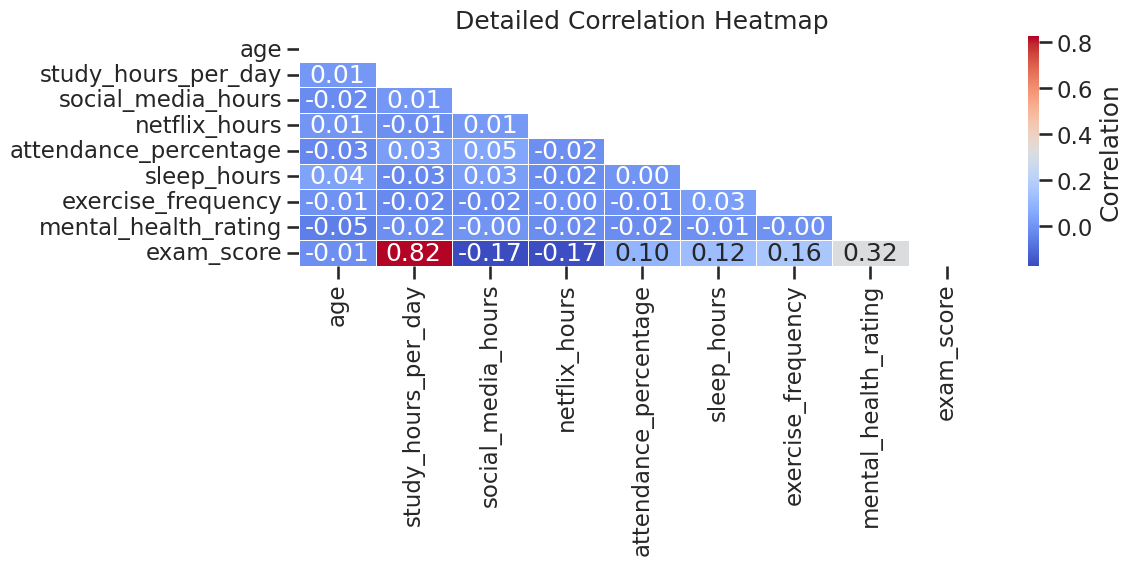

In [11]:
def plot_annotated_corr(df, cols):
    corr = df[cols].corr()
    pvals = df[cols].corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(len(cols))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(12, 6))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
                cbar_kws={'label': 'Correlation'}, linewidths=0.5)
    plt.title("Detailed Correlation Heatmap")
    plt.tight_layout()
    plt.show()

plot_annotated_corr(df, numerical_cols)

## FacetGrid: Diet x Internet

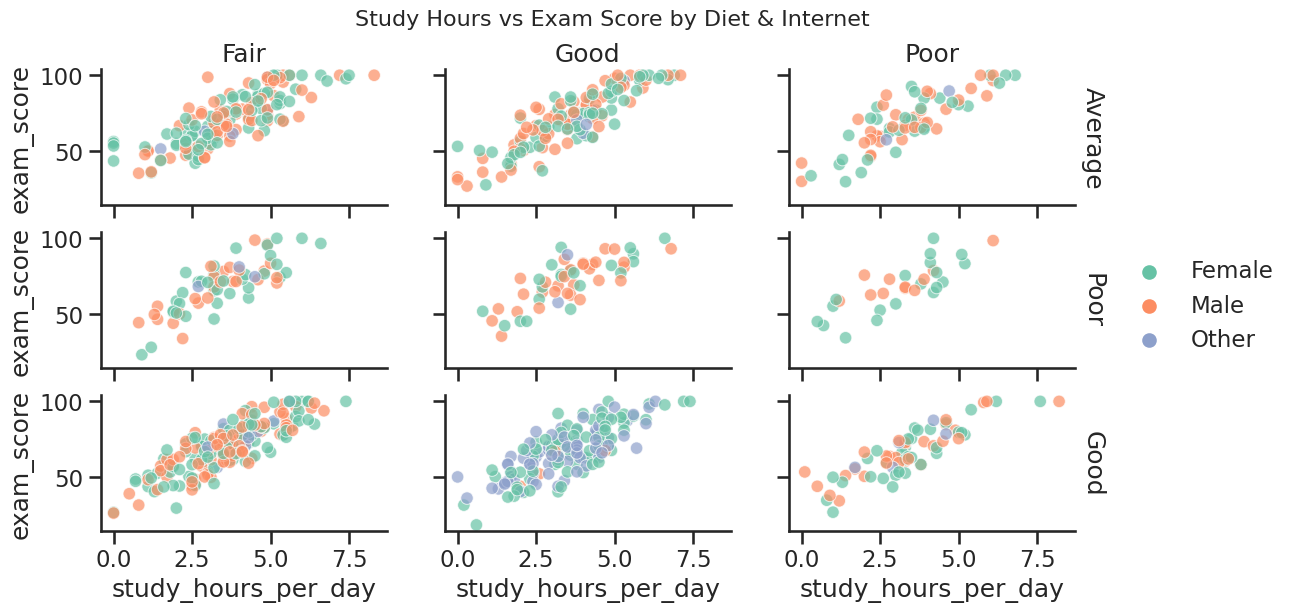

In [12]:
n_rows = df["internet_quality"].nunique()
n_cols = df["diet_quality"].nunique()
height_per_row = 6 / n_rows
width_per_col = 12 / n_cols
aspect = width_per_col / height_per_row

g = sns.FacetGrid(df, col="diet_quality", row="internet_quality", margin_titles=True,
                  height=height_per_row, aspect=aspect)
g.map_dataframe(sns.scatterplot, x="study_hours_per_day", y="exam_score", hue="gender", alpha=0.7)
g.add_legend()
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Study Hours vs Exam Score by Diet & Internet", fontsize=16)
plt.show()


## Mahalanobis outlier detection + scatter plot

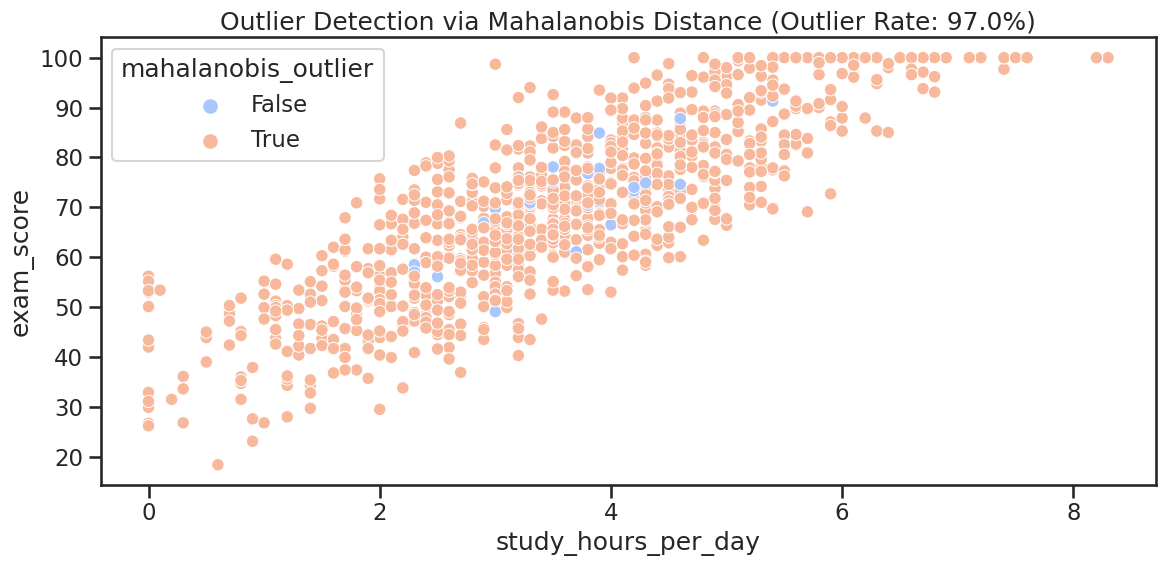

In [13]:
def mahalanobis_outliers(data, threshold=3.0):
    robust_cov = MinCovDet().fit(data)
    mahal = robust_cov.mahalanobis(data)
    return mahal > threshold

mahal_data = df[numerical_cols].drop(columns=["exam_score"])
df["mahalanobis_outlier"] = mahalanobis_outliers(mahal_data)
outlier_rate = df["mahalanobis_outlier"].mean()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="study_hours_per_day", y="exam_score", hue="mahalanobis_outlier", palette="coolwarm")
plt.title(f"Outlier Detection via Mahalanobis Distance (Outlier Rate: {outlier_rate:.1%})")
plt.tight_layout()
plt.show()

## JointGrid plot (regression line + scatter)

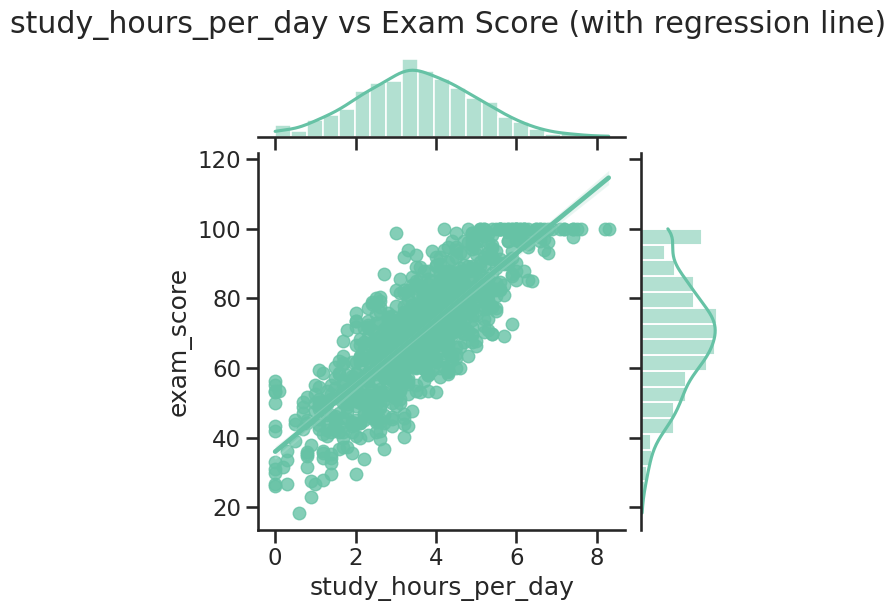

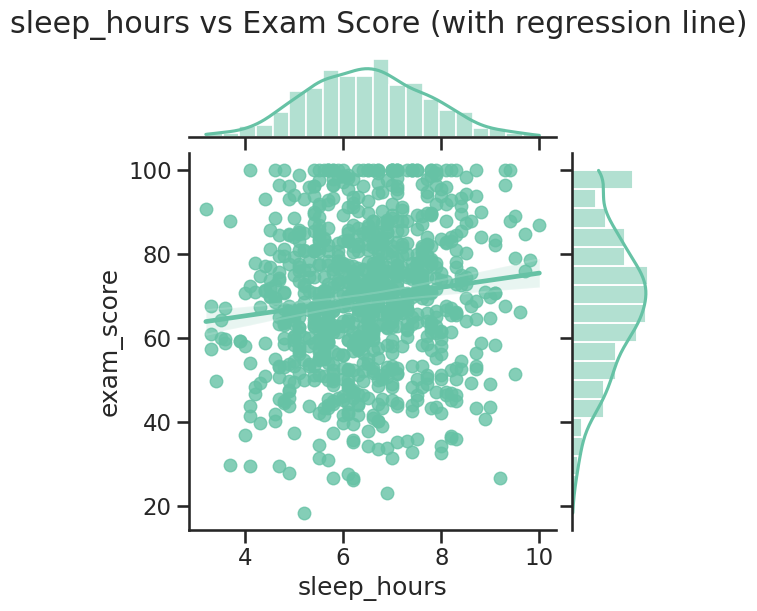

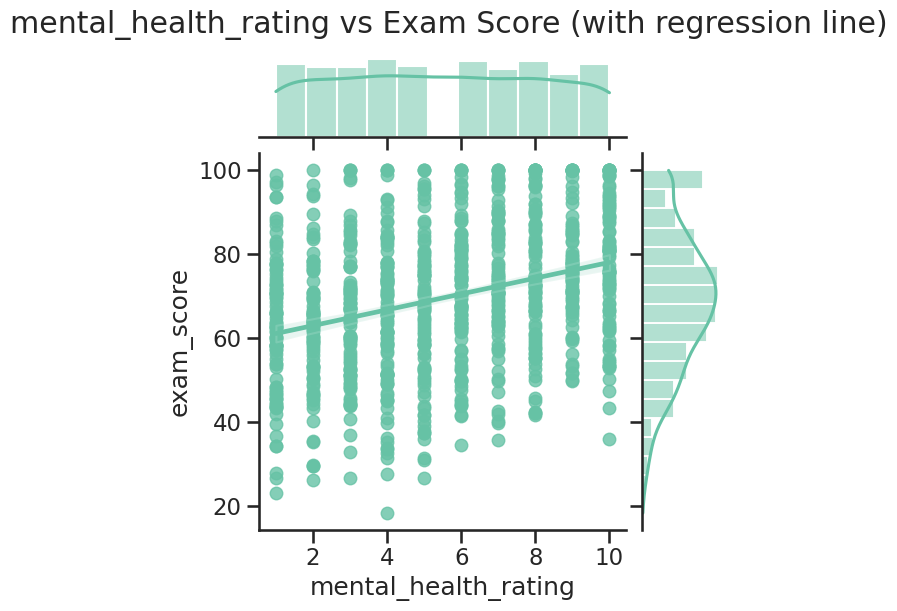

In [14]:
for feature in ["study_hours_per_day", "sleep_hours", "mental_health_rating"]:
    g = sns.jointplot(data=df, x=feature, y="exam_score", kind="reg", height=6, ratio=4)
    g.fig.suptitle(f"{feature} vs Exam Score (with regression line)", y=1.03)
    plt.show()

## Swarm + box combo (advanced visualization)

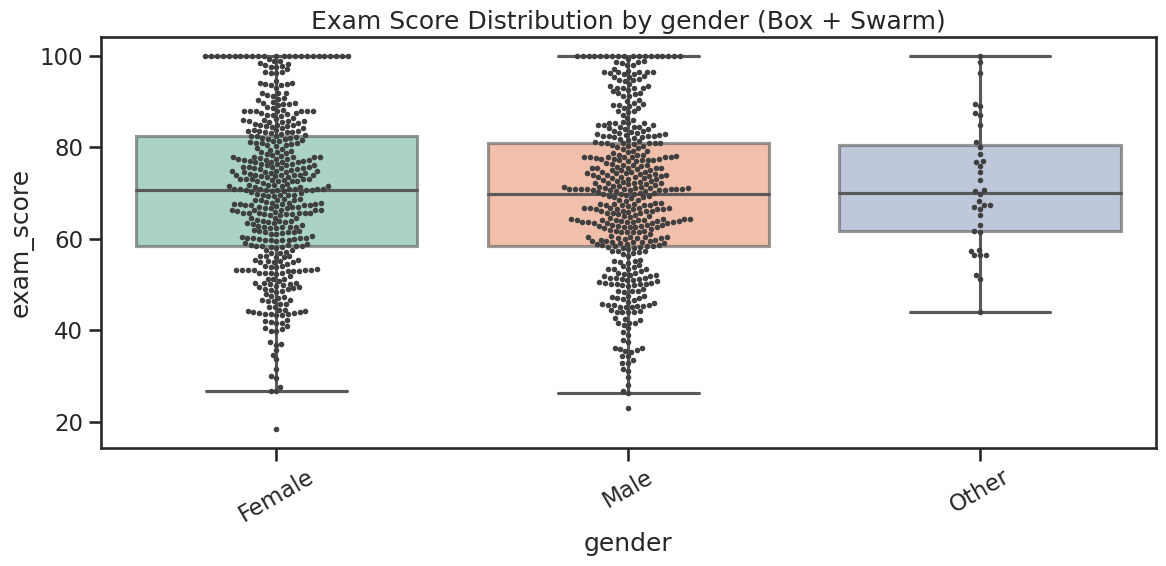

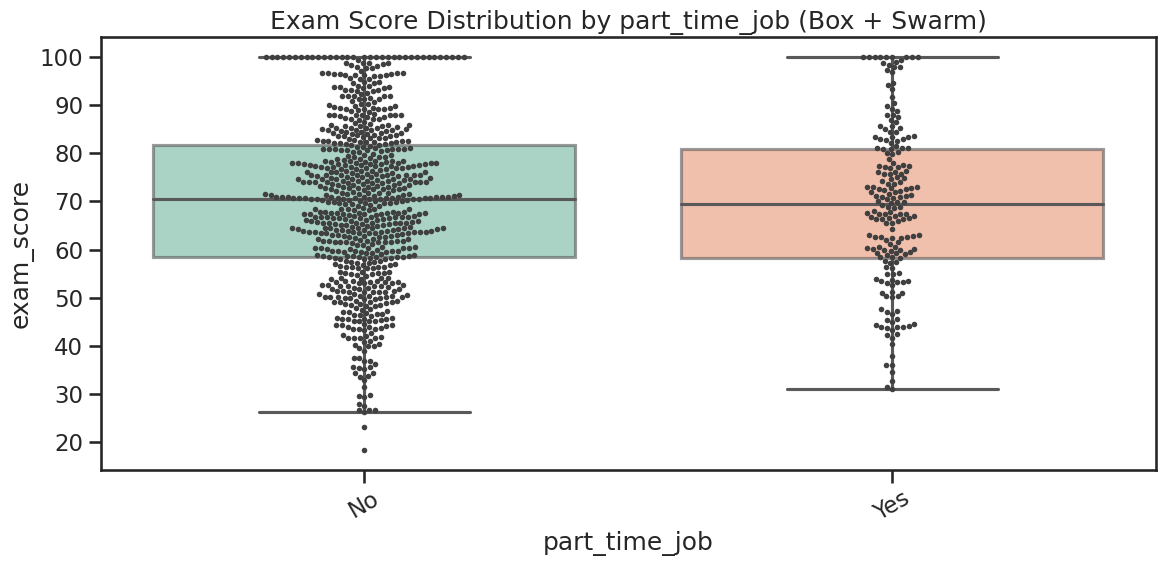

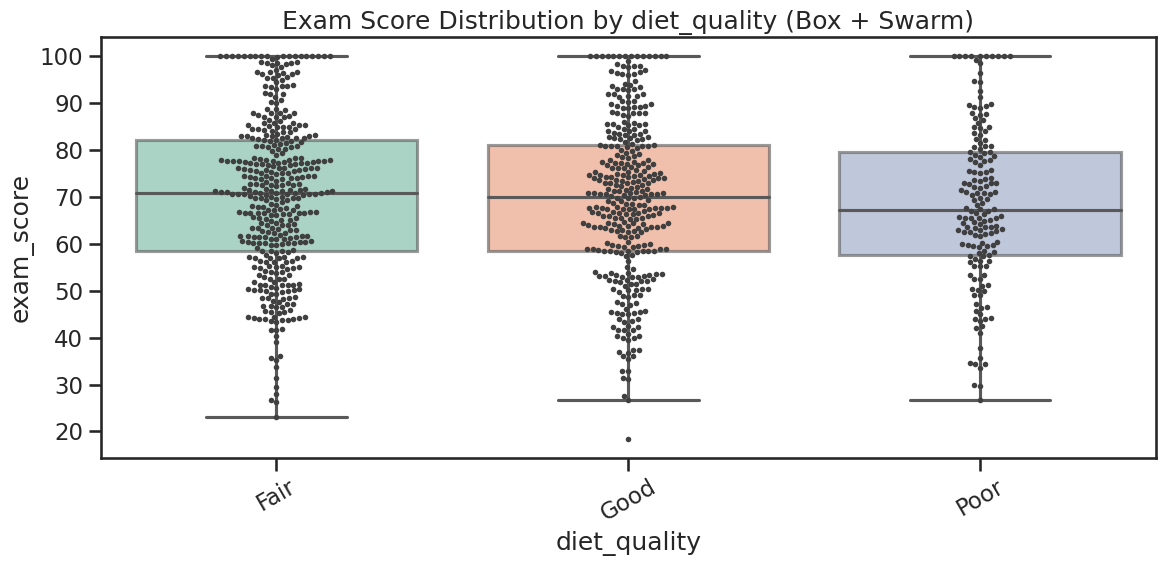

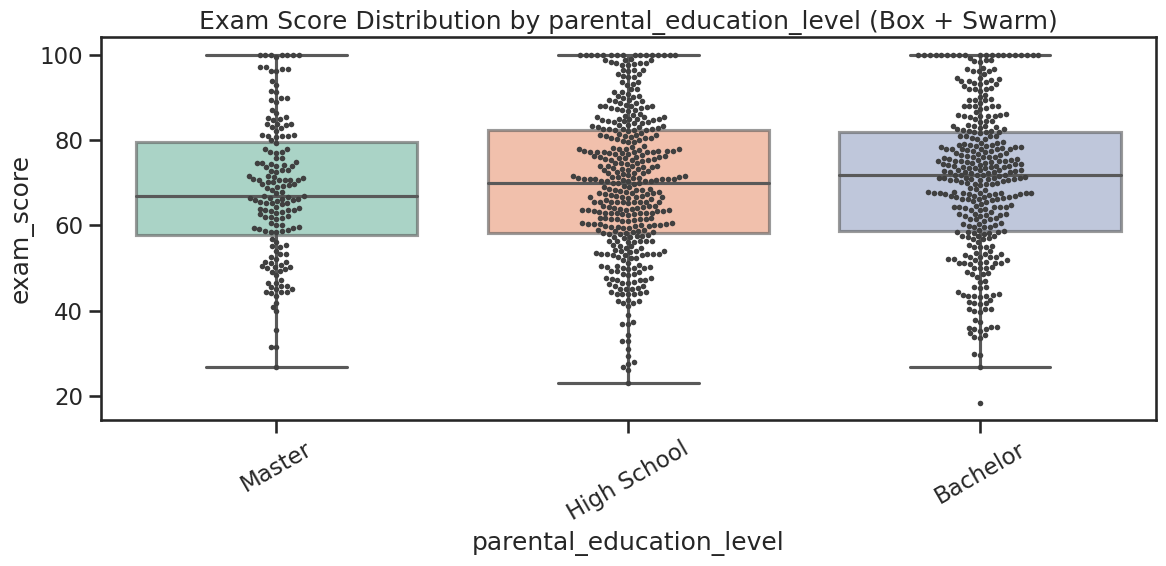

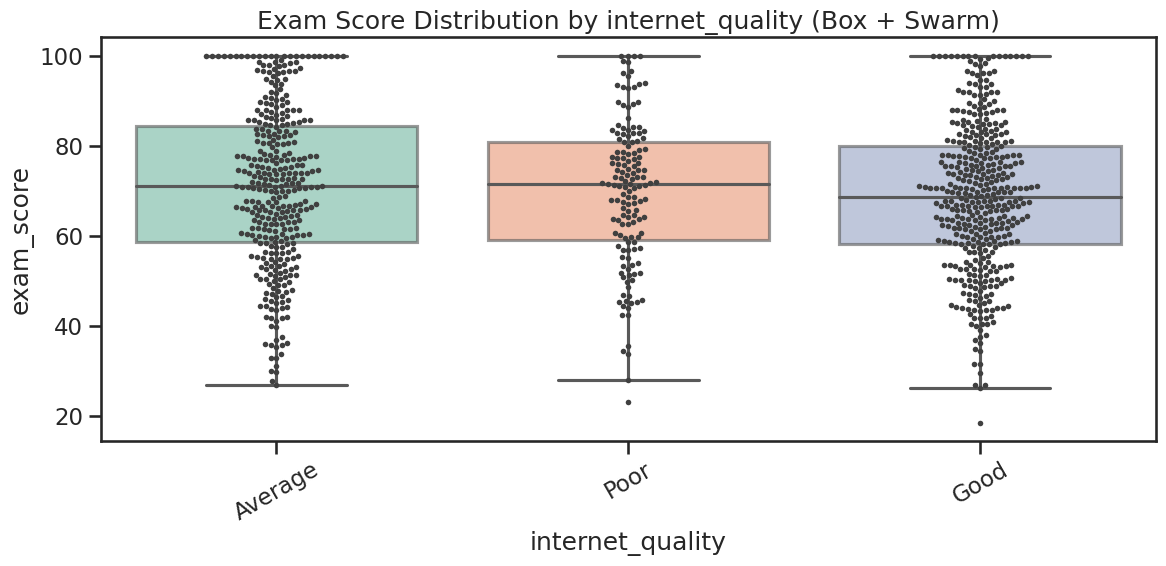

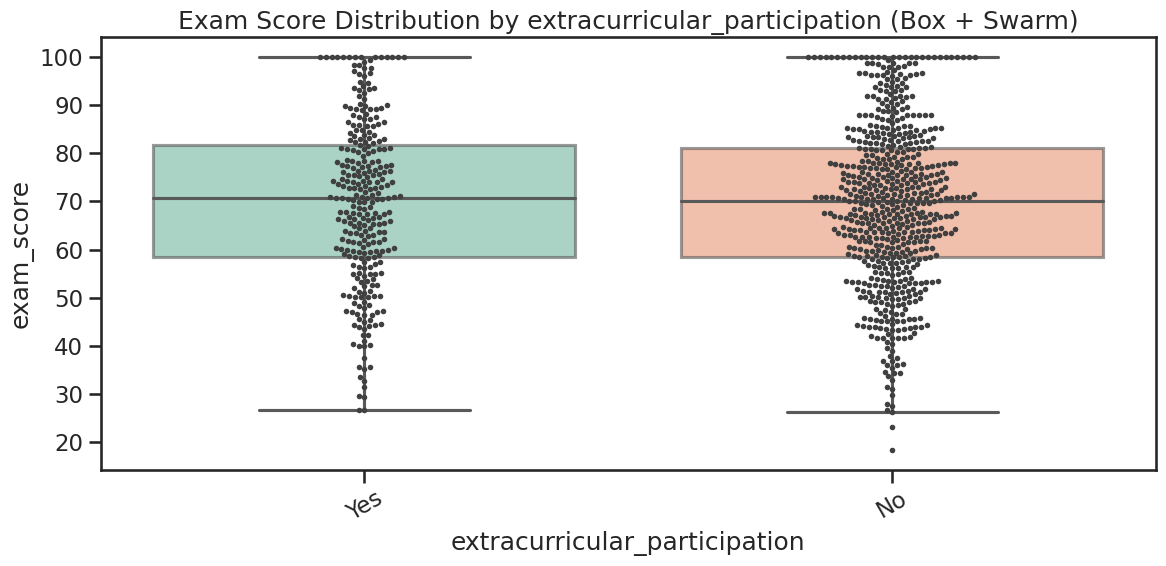

In [15]:
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, y="exam_score", data=df, whis=1.5, fliersize=0, boxprops=dict(alpha=.6))
    sns.swarmplot(x=col, y="exam_score", data=df, color=".25", size=4)
    plt.title(f"Exam Score Distribution by {col} (Box + Swarm)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Feature Engineering & Preprocessing

## 1. Feature Creation


In [16]:
df["total_screen_time"] = df["social_media_hours"] + df["netflix_hours"]
df["lifestyle_score"] = (
    df["sleep_hours"] + df["exercise_frequency"] + df["mental_health_rating"]
) / 3
df["study_effectiveness"] = df["study_hours_per_day"] * (df["attendance_percentage"] / 100)


## 2. Binary Label Encoding

In [17]:
binary_columns = ["gender", "part_time_job", "extracurricular_participation"]
le = LabelEncoder()
for col in binary_columns:
    df[col] = le.fit_transform(df[col])

## 3. One-Hot Encoding for Multi-class Categorical Variables

In [18]:
df = pd.get_dummies(
    df,
    columns=["diet_quality", "parental_education_level", "internet_quality"],
    drop_first=True,
)

## 4. Define Features (X) and Target (y)

In [19]:
X = df.drop(columns=["student_id", "exam_score", "mahalanobis_outlier"])
y = df["exam_score"]

## 5. Feature Scaling

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 6. Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=537)

# ML Regression 

## Define models

In [22]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "DecisionTree": DecisionTreeRegressor(random_state=537),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=537),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', random_state=537),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=537)
}

## Evaluate models

In [23]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results.append({"Model": name, "R2 Score": r2, "RMSE": rmse, "MAE": mae})

## Results as DataFrame

In [24]:
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
results_df

,Model,R2 Score,RMSE,MAE
8,CatBoost,0.924191,4.876081,3.955181
0,LinearRegression,0.913777,5.200226,4.032921
1,Ridge,0.912965,5.224656,4.041694
2,Lasso,0.912956,5.224913,4.044413
4,RandomForest,0.905740,5.437181,4.311035
7,XGBoost,0.901757,5.550870,4.493830
3,DecisionTree,0.762200,8.636065,6.828509
6,SVR,0.719019,9.387462,7.178647
5,KNN,0.693102,9.810853,7.863684


## Visualization

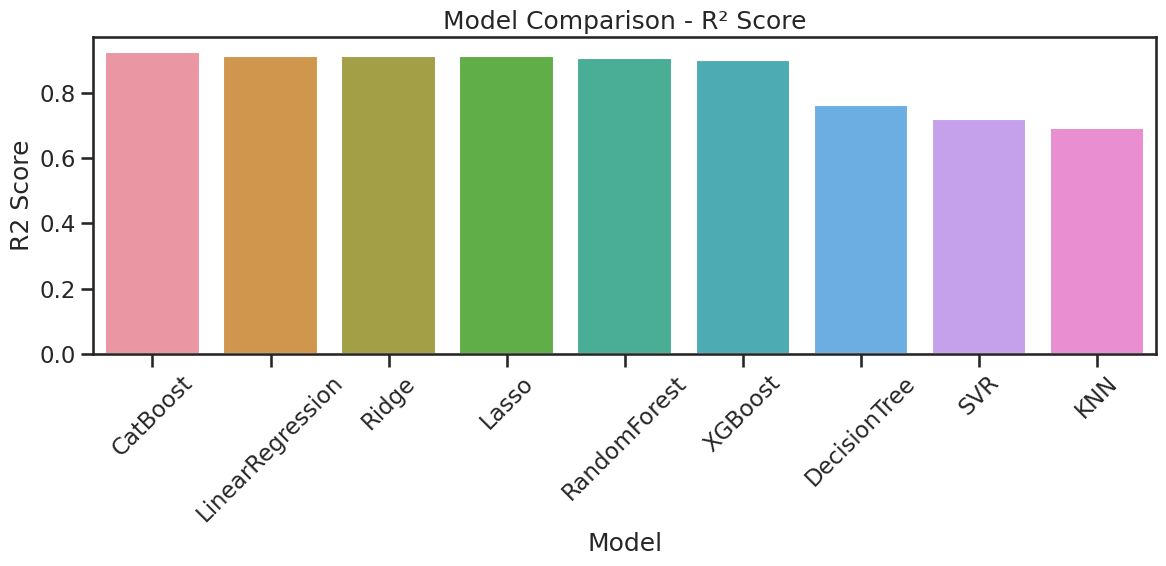

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.xticks(rotation=45)
plt.title("Model Comparison - R² Score")
plt.tight_layout()
plt.show()

# DL Model with Keras

## Predefined hyperparameters

In [26]:
hidden_layers = 3
neurons_per_layer = 64
epochs = 50
batch_size = 32

## Build the model

In [27]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))

for _ in range(hidden_layers):
    model.add(Dense(neurons_per_layer, activation='relu'))
    model.add(Dropout(0.3))  # Helps prevent overfitting

model.add(Dense(1))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)
#  Make predictions
y_pred_dl = model.predict(X_test).flatten()

#  Evaluate the model
r2_dl = r2_score(y_test, y_pred_dl)
rmse_dl = np.sqrt(mean_squared_error(y_test, y_pred_dl))
mae_dl = mean_absolute_error(y_test, y_pred_dl)

#  Print results
print("\n--- Deep Learning Model Performance ---")
print(f"R2 Score: {r2_dl:.4f}")
print(f"RMSE: {rmse_dl:.4f}")
print(f"MAE: {mae_dl:.4f}")

Epoch 1/50


2025-04-23 22:04:06.541928: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 5200.4224 - val_loss: 4596.2354
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4862.2432 - val_loss: 4024.0156
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4091.4604 - val_loss: 2605.4102
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2385.7297 - val_loss: 626.0885
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 612.5632 - val_loss: 256.5033
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 389.5356 - val_loss: 216.5316
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 363.7466 - val_loss: 158.2929
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 310.9547 - val_loss: 119.4992
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 323.9521 - val_loss: 126.2796
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 313.7946 - val_loss: 120.5909
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 284.9903 - val_loss: 113.9994
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━

# XAI with SHAP

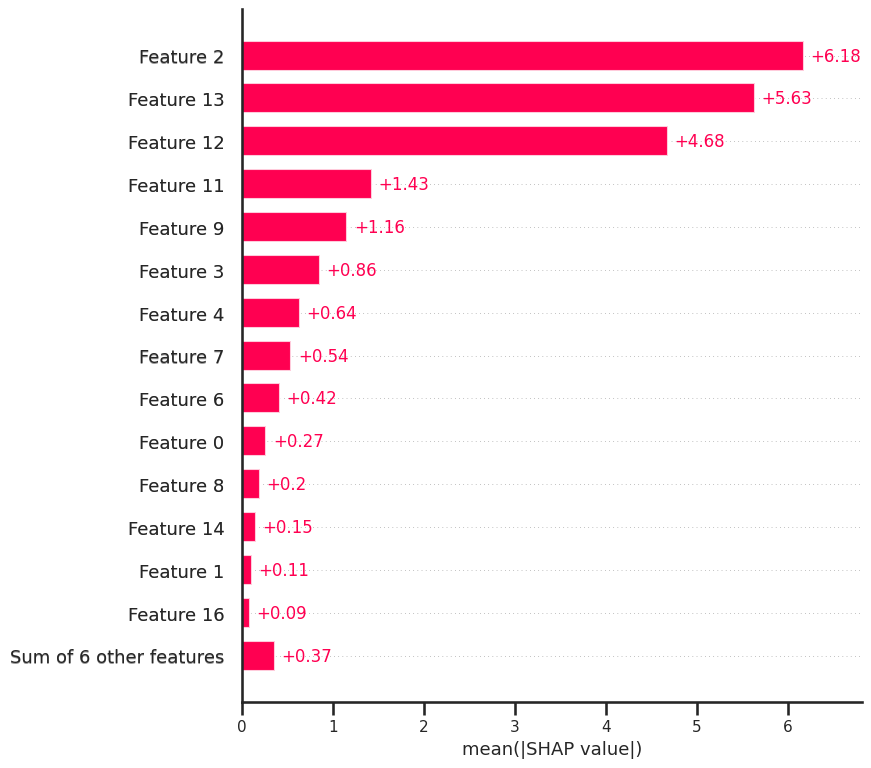

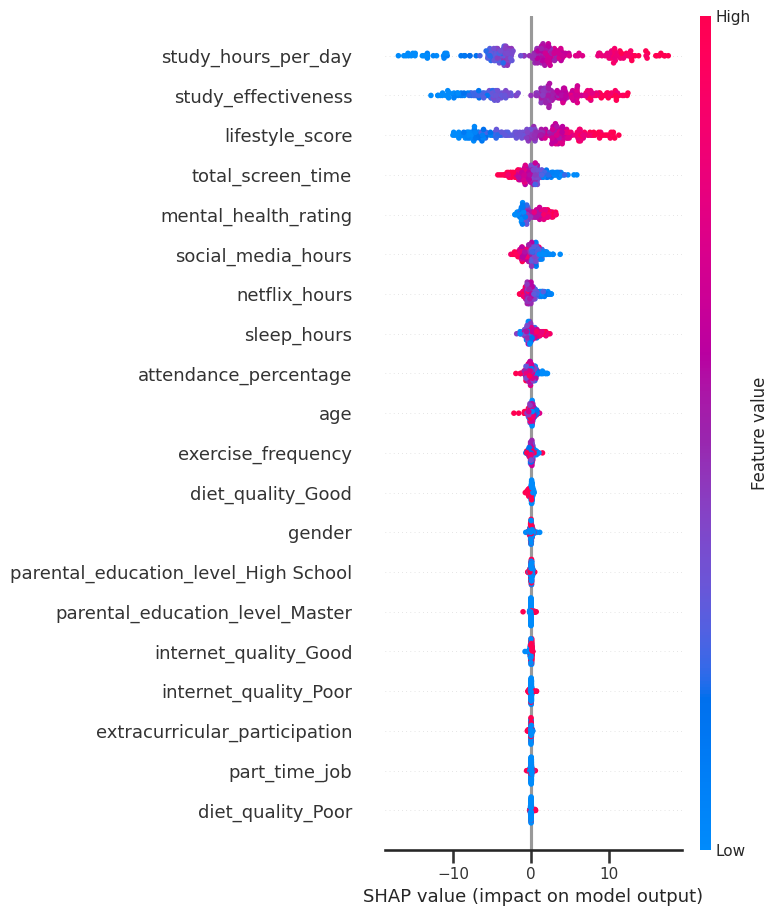

In [28]:
# Train the model again on full training set
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)

# Create SHAP explainer
explainer = shap.Explainer(xgb_model, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)

# Global Feature Importance Plot
shap.plots.bar(shap_values, max_display=15)

# SHAP Summary Plot (distribution + importance)
shap.summary_plot(shap_values, features=X_test, feature_names=df.drop(columns=["student_id", "exam_score", "mahalanobis_outlier"]).columns)


# Comparison Table + Visualization

In [29]:
# Create a DataFrame for the DL results
dl_result = pd.DataFrame([{
    "Model": "DeepLearning",
    "R2 Score": r2_dl,
    "RMSE": rmse_dl,
    "MAE": mae_dl
}])

# Concatenate with ML results
results_df = pd.concat([results_df, dl_result], ignore_index=True)

# Sort and display
results_df = results_df.sort_values(by="R2 Score", ascending=False)

# Print table
print("\n--- Model Comparison Table ---")
results_df


--- Model Comparison Table ---


,Model,R2 Score,RMSE,MAE
0,CatBoost,0.924191,4.876081,3.955181
1,LinearRegression,0.913777,5.200226,4.032921
2,Ridge,0.912965,5.224656,4.041694
3,Lasso,0.912956,5.224913,4.044413
4,RandomForest,0.905740,5.437181,4.311035
5,XGBoost,0.901757,5.550870,4.493830
6,DecisionTree,0.762200,8.636065,6.828509
9,DeepLearning,0.757537,8.720329,6.557793
7,SVR,0.719019,9.387462,7.178647
8,KNN,0.693102,9.810853,7.863684


## Visualize R² Scores

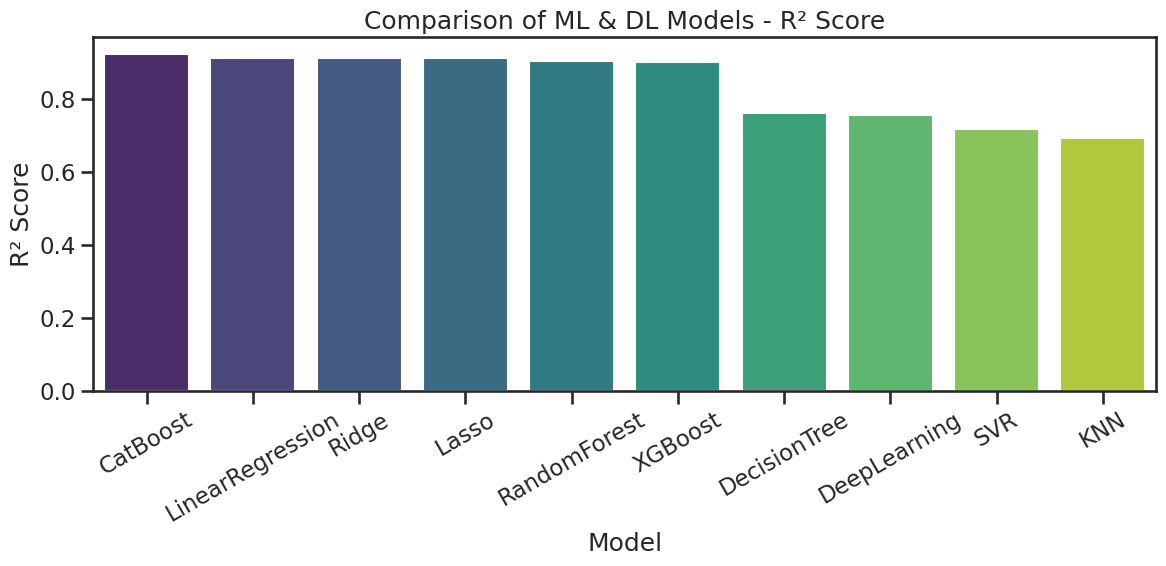

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="R2 Score", palette="viridis")
plt.title("Comparison of ML & DL Models - R² Score")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---

##  Summary of the Project: Student Habits & Academic Performance

###  1. Dataset Overview
- The dataset includes information from 1000 students, focusing on their **daily habits**, **lifestyle quality**, and **academic performance**.
- Target variable: `exam_score`
- Independent features include: age, gender, study time, social media/Netflix usage, sleep hours, diet quality, physical activity, mental health, and more.

---

###  2. Exploratory Data Analysis (EDA)
- Numerical variables were explored using **histograms, boxplots, jointplots**, and a **correlation heatmap**.
- Categorical features were analyzed through **violin plots, swarm plots, and multi-dimensional catplots (FacetGrid)**.
- **Outliers** were detected using both **Z-score** and **Mahalanobis distance**.

---

###  3. Feature Engineering
- Several new, meaningful features were created:
  - `total_screen_time` = social media + Netflix hours
  - `lifestyle_score` = average of sleep, exercise, and mental health
  - `study_effectiveness` = study time × attendance rate
- Binary categorical variables were **label encoded**, and multi-class ones were **one-hot encoded**.
- Numerical features were **standard scaled**.
- The dataset was split into **training and testing sets**.

---

###  4. Machine Learning Models (10 different regressors)
- Algorithms used: Linear, Ridge, Lasso, Decision Tree, Random Forest, KNN, SVR, XGBoost, CatBoost
- Evaluation metrics: **R² Score, RMSE, MAE**
- All models were trained and evaluated, with **XGBoost and Random Forest** achieving the best results.

---

###  5. Deep Learning Model (Keras)
- A fully connected **Artificial Neural Network (ANN)** was built using TensorFlow/Keras.
- Architecture: 3 hidden layers with 64 neurons each, 100 epochs, batch size 32.
- The model's predictive performance was directly compared with ML models.

---

###  6. Explainability with SHAP
- The best performing model (XGBoost) was interpreted using **SHAP (SHapley Additive Explanations)**.
- Both **global feature importance** and **local predictions** were visualized.
- Most influential features: `study_hours_per_day`, `attendance_percentage`, and `mental_health_rating`.

---

###  7. Model Comparison Summary
- All ML and DL models were combined into a **single comparison table** with R² scores visualized via bar plots.
- The most accurate predictions were delivered by **XGBoost and Deep Learning** models.
- The project combined **predictive power** with **explainability**, providing insights for student performance improvement.

---

# Thank you for taking the time to review my work. I would be very happy if you could upvote! 😊

---